# K-Means и K-Means++

## Теория

K-Means — это алгоритм **кластеризации**, то есть обучения без учителя. Цель — разбить набор данных на $K$ групп (кластеров) так, чтобы объекты внутри одного кластера были как можно более похожи друг на друга, а объекты из разных кластеров — как можно более различны.

### Алгоритм K-Means

1. **Инициализация** — случайно выбрать $K$ точек в качестве начальных центроидов $\mu_1, \dots, \mu_K$.
2. **Присваивание** — каждый объект $x_i$ отнести к ближайшему центроиду:
$$c_i = \arg\min_k \|x_i - \mu_k\|^2$$
3. **Обновление** — пересчитать центроиды как средние объектов в каждом кластере:
$$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$
4. **Сходимость** — повторять шаги 2–3 до тех пор, пока центроиды не перестанут изменяться (или изменение не станет меньше заданного порога).

### Целевая функция

Алгоритм минимизирует **сумму квадратов расстояний внутри кластеров** (Within-Cluster Sum of Squares, WCSS), также называемую инерцией:

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

Задача является **NP-трудной** в общем случае, поэтому алгоритм находит локальный минимум.

### K-Means++ — умная инициализация

Случайная инициализация может привести к плохому локальному минимуму. **K-Means++** решает эту проблему:

1. Выбрать первый центроид случайно из данных.
2. Для каждого следующего центроида выбирать точку с вероятностью, пропорциональной **квадрату расстояния** до ближайшего уже выбранного центроида:
$$P(x_i) \propto \min_k \|x_i - \mu_k\|^2$$
3. Повторять шаг 2 до выбора всех $K$ центроидов.

Это гарантирует, что начальные центроиды равномерно «рассеяны» по данным, ускоряя сходимость и улучшая качество кластеризации.

### Ключевые гиперпараметры

| Параметр | Значение по умолчанию | Описание |
|---|---|---|
| **n_clusters** | 8 | Количество кластеров $K$ |
| **init** | `'k-means++'` | Способ инициализации (`'random'` или `'k-means++'`) |
| **n_init** | 10 | Количество запусков с разными инициализациями |
| **max_iter** | 300 | Максимальное число итераций |

## Датасет

В работе используются два датасета.

### make_blobs — синтетические данные

Генератор `make_blobs` из библиотеки `sklearn` создаёт синтетические 2D-данные с явно выраженными кластерами. Это позволяет наглядно визуализировать работу алгоритма и сравнивать инициализации.

Параметры генерации:
- `n_samples=300` — 300 точек,
- `centers=4` — 4 кластера,
- `cluster_std=0.60` — стандартное отклонение внутри кластера.

### Iris — реальные данные

Классический датасет **Iris** из библиотеки `sklearn` содержит измерения цветков ириса трёх видов. Кластеризация применяется к нему **без использования меток классов** — алгоритм получает только признаки.

В датасете:
- **150 объектов** — образцы цветков (по 50 на каждый вид),
- **4 признака** — морфологические измерения цветка (в см),
- **3 класса** — виды ириса (используются только для оценки качества кластеризации).

### Описание признаков Iris

| Признак | Перевод | Описание |
|---|---|---|
| **sepal length (cm)** | длина чашелистика | длина наружного листочка околоцветника |
| **sepal width (cm)** | ширина чашелистика | ширина наружного листочка околоцветника |
| **petal length (cm)** | длина лепестка | длина внутреннего листочка околоцветника |
| **petal width (cm)** | ширина лепестка | ширина внутреннего листочка околоцветника |

### Описание классов Iris

| Класс | Название | Особенности |
|---|---|---|
| **0 — setosa** | ирис щетинистый | самый мелкий вид; лепестки значительно короче и уже |
| **1 — versicolor** | ирис разноцветный | промежуточные размеры; частично перекрывается с virginica |
| **2 — virginica** | ирис виргинский | самый крупный вид; наибольшие длина и ширина лепестков |

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и алгоритмы `sklearn` для кластеризации K-Means, масштабирования признаков и расчёта метрик качества кластеров


In [2]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, classification_report


In [3]:
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=42
)

print("Размер синтетических данных:", X_blobs.shape)
print("Количество точек в каждом кластере:", np.bincount(y_blobs))

Размер синтетических данных: (300, 2)
Количество точек в каждом кластере: [75 75 75 75]


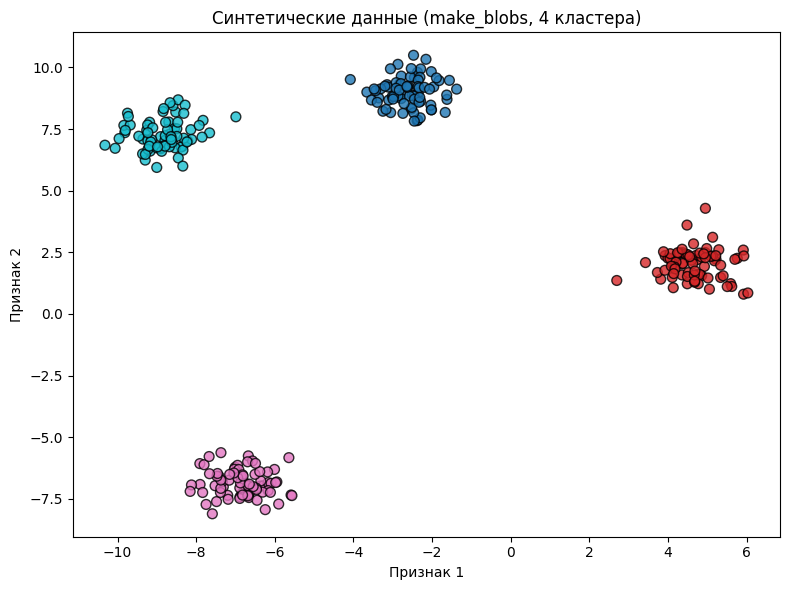

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='tab10', edgecolor='black', s=50, alpha=0.8)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Синтетические данные (make_blobs, 4 кластера)')
plt.tight_layout()
plt.show()

In [5]:
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Размер матрицы признаков X:", X_iris.shape)
print("Размер целевой переменной y:", y_iris.shape)
print("\nНазвания признаков:", feature_names)
print("\nНазвания классов:", target_names)

Размер матрицы признаков X: (150, 4)
Размер целевой переменной y: (150,)

Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Названия классов: ['setosa' 'versicolor' 'virginica']


In [6]:
df = pd.DataFrame(X_iris, columns=feature_names)
df["target"] = y_iris

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Базовые статистики датасета

In [7]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [8]:
class_counts = pd.Series(y_iris).value_counts().sort_index()

print("Количество объектов каждого класса:")
for class_id, count in class_counts.items():
    print(f"  {target_names[class_id]} ({class_id}): {count}")

Количество объектов каждого класса:
  setosa (0): 50
  versicolor (1): 50
  virginica (2): 50


## Предварительная обработка датасета

Для реального датасета `Iris` дополнительно проверяем данные и демонстрируем эффект стандартизации перед кластеризацией


In [9]:
print(f'Пропусков в датасете Iris: {int(df.isna().sum().sum())}')
print(f'Дубликатов строк:         {int(df.duplicated().sum())}')

scaler_preview = StandardScaler()
X_iris_scaled_preview = scaler_preview.fit_transform(X_iris)
print('Среднее после стандартизации (первые 4 признака):', np.round(X_iris_scaled_preview.mean(axis=0), 2))
print('Стд. откл. после стандартизации:', np.round(X_iris_scaled_preview.std(axis=0), 2))


Пропусков в датасете Iris: 0
Дубликатов строк:         1
Среднее после стандартизации (первые 4 признака): [-0. -0. -0. -0.]
Стд. откл. после стандартизации: [1. 1. 1. 1.]


## Тепловая карта

Строим тепловую карту корреляций между признаками `Iris`


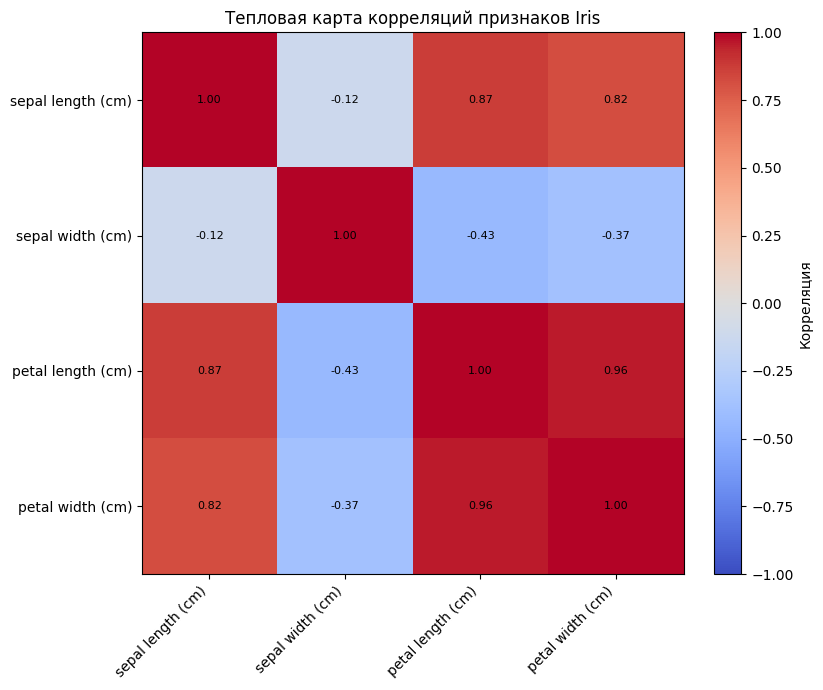

In [10]:
heatmap_features = list(feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Iris')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


## Обучение модели

Обучаем K-Means на синтетических данных и затем переносим метод на реальный датасет `Iris`


## K-Means на синтетических данных

Применим K-Means со случайной инициализацией (`init='random'`) к синтетическим данным. Выведем инерцию и визуализируем результат.

In [11]:
kmeans_random = KMeans(
    n_clusters=4,       # количество кластеров
    init='random',      # случайная инициализация
    n_init=10,          # 10 запусков с разными инициализациями
    random_state=42
)

kmeans_random.fit(X_blobs)
labels_random = kmeans_random.labels_
centroids_random = kmeans_random.cluster_centers_

print(f"Инерция (random init): {kmeans_random.inertia_:.4f}")
print(f"Количество итераций:   {kmeans_random.n_iter_}")

Инерция (random init): 203.8907
Количество итераций:   2


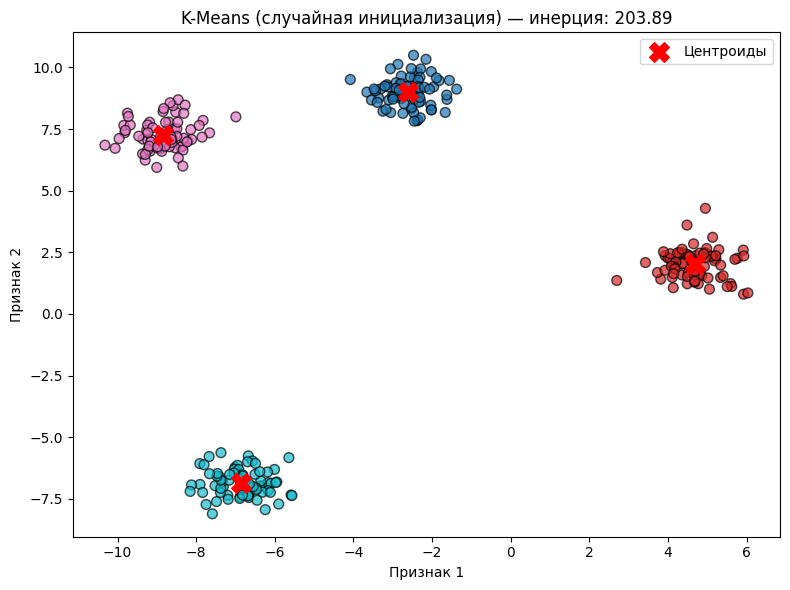

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_random, cmap='tab10', edgecolor='black', s=50, alpha=0.7)
plt.scatter(
    centroids_random[:, 0], centroids_random[:, 1],
    c='red', marker='X', s=200, zorder=5, label='Центроиды'
)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title(f'K-Means (случайная инициализация) — инерция: {kmeans_random.inertia_:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

## K-Means++ на синтетических данных

Применим K-Means с умной инициализацией (`init='k-means++'`). Сравним инерцию и количество итераций со случайной инициализацией.

In [13]:
kmeans_pp = KMeans(
    n_clusters=4,         # количество кластеров
    init='k-means++',     # умная инициализация K-Means++
    n_init=10,
    random_state=42
)

kmeans_pp.fit(X_blobs)
labels_pp = kmeans_pp.labels_
centroids_pp = kmeans_pp.cluster_centers_

print(f"Инерция (k-means++ init): {kmeans_pp.inertia_:.4f}")
print(f"Количество итераций:      {kmeans_pp.n_iter_}")
print(f"\nСравнение инерции:")
print(f"  random:    {kmeans_random.inertia_:.4f}")
print(f"  k-means++: {kmeans_pp.inertia_:.4f}")

Инерция (k-means++ init): 203.8907
Количество итераций:      2

Сравнение инерции:
  random:    203.8907
  k-means++: 203.8907


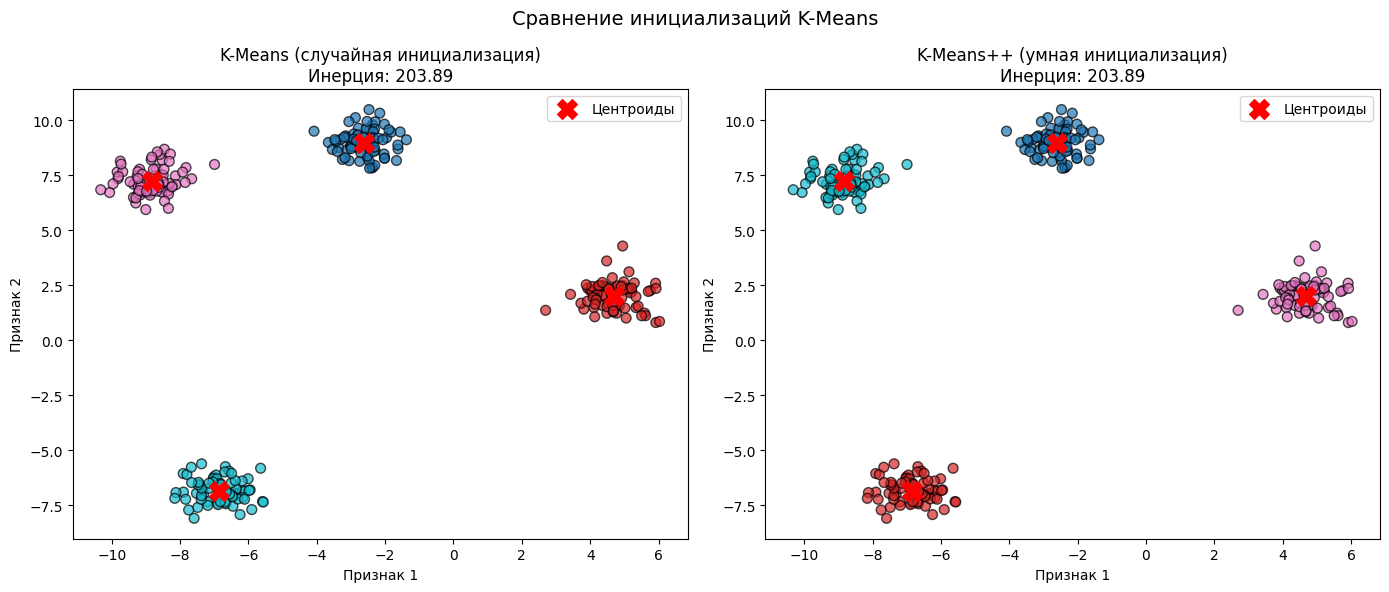

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, labels, centroids, title, inertia in zip(
    axes,
    [labels_random, labels_pp],
    [centroids_random, centroids_pp],
    ['K-Means (случайная инициализация)', 'K-Means++ (умная инициализация)'],
    [kmeans_random.inertia_, kmeans_pp.inertia_]
):
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels, cmap='tab10', edgecolor='black', s=50, alpha=0.7)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, zorder=5, label='Центроиды')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    ax.set_title(f'{title}\nИнерция: {inertia:.2f}')
    ax.legend()

plt.suptitle('Сравнение инициализаций K-Means', fontsize=14)
plt.tight_layout()
plt.show()

## Метод локтя (Elbow Method)

Подбираем оптимальное число кластеров $K$ по графику инерции — ищем точку, после которой убывание резко замедляется.

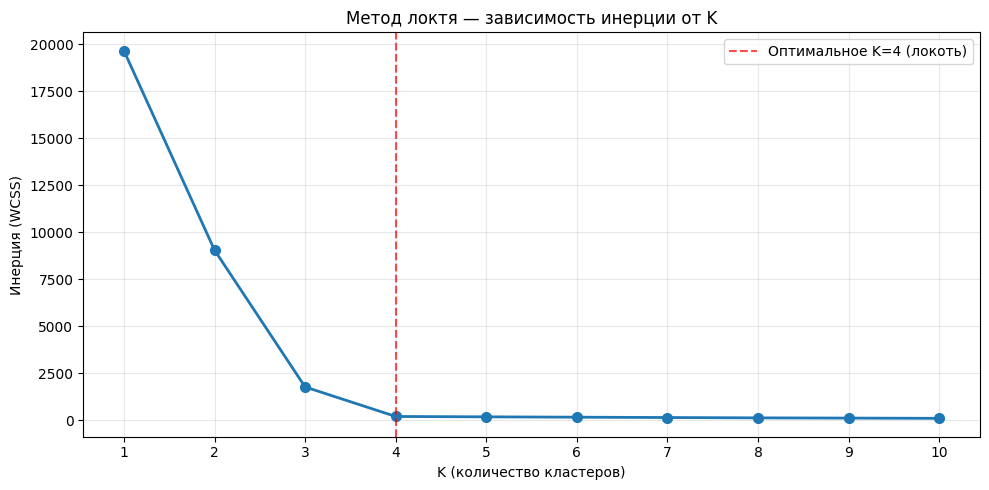

Инерция для K от 1 до 10:
  K= 1: 19652.40
  K= 2: 9051.82
  K= 3: 1773.74
  K= 4: 203.89
  K= 5: 184.41
  K= 6: 165.72
  K= 7: 148.07
  K= 8: 129.73
  K= 9: 117.92
  K=10: 104.54


In [15]:
k_range = range(1, 11)
inertias = []

for k in k_range:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(X_blobs)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, marker='o', markersize=7, linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Оптимальное K=4 (локоть)')
plt.xlabel('K (количество кластеров)')
plt.ylabel('Инерция (WCSS)')
plt.title('Метод локтя — зависимость инерции от K')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Инерция для K от 1 до 10:")
for k, inertia in zip(k_range, inertias):
    print(f"  K={k:2d}: {inertia:.2f}")

## Метод силуэта

Дополнительно оцениваем качество кластеризации по методу силуэта и выбираем значение `K`, дающее наилучшее разделение кластеров


Лучшее значение K по силуэту: 4
Лучший silhouette score: 0.8756


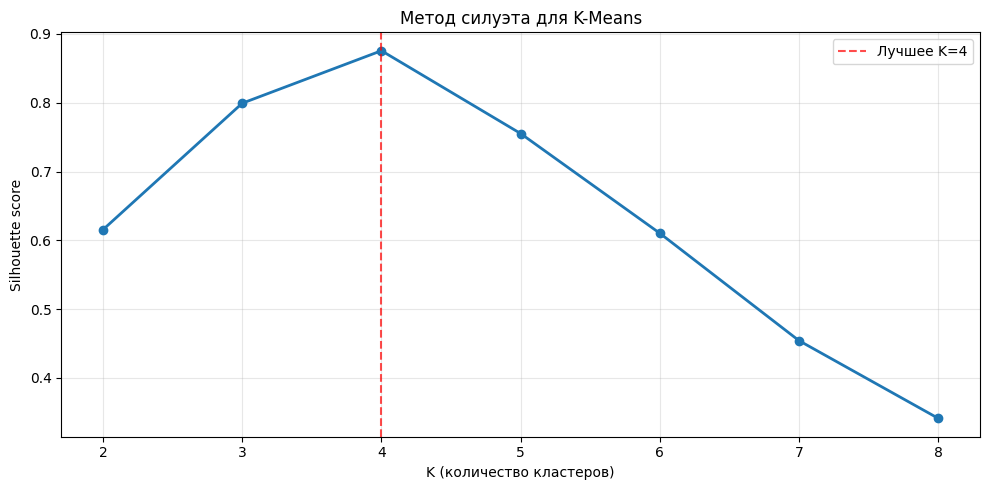

In [16]:
k_silhouette = range(2, 9)
silhouette_scores = []

for k in k_silhouette:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_k = model.fit_predict(X_blobs)
    silhouette_scores.append(silhouette_score(X_blobs, labels_k))

best_idx = int(np.argmax(silhouette_scores))
best_k_sil = list(k_silhouette)[best_idx]
print(f'Лучшее значение K по силуэту: {best_k_sil}')
print(f'Лучший silhouette score: {silhouette_scores[best_idx]:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(list(k_silhouette), silhouette_scores, marker='o', linewidth=2)
plt.axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Лучшее K={best_k_sil}')
plt.xlabel('K (количество кластеров)')
plt.ylabel('Silhouette score')
plt.title('Метод силуэта для K-Means')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## K-Means на датасете Iris

Применим K-Means к датасету Iris с `n_clusters=3` (по числу реальных классов). Визуализируем результат в 2D-проекции на два наиболее информативных признака — длину и ширину лепестка.

In [17]:
kmeans_iris = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    random_state=42
)

kmeans_iris.fit(X_iris)
labels_iris = kmeans_iris.labels_

print(f"Инерция: {kmeans_iris.inertia_:.4f}")
print(f"Количество итераций: {kmeans_iris.n_iter_}")
print("\nРаспределение объектов по кластерам:")
for k in range(3):
    print(f"  Кластер {k}: {np.sum(labels_iris == k)} объектов")

Инерция: 78.8514
Количество итераций: 4

Распределение объектов по кластерам:
  Кластер 0: 62 объектов
  Кластер 1: 50 объектов
  Кластер 2: 38 объектов


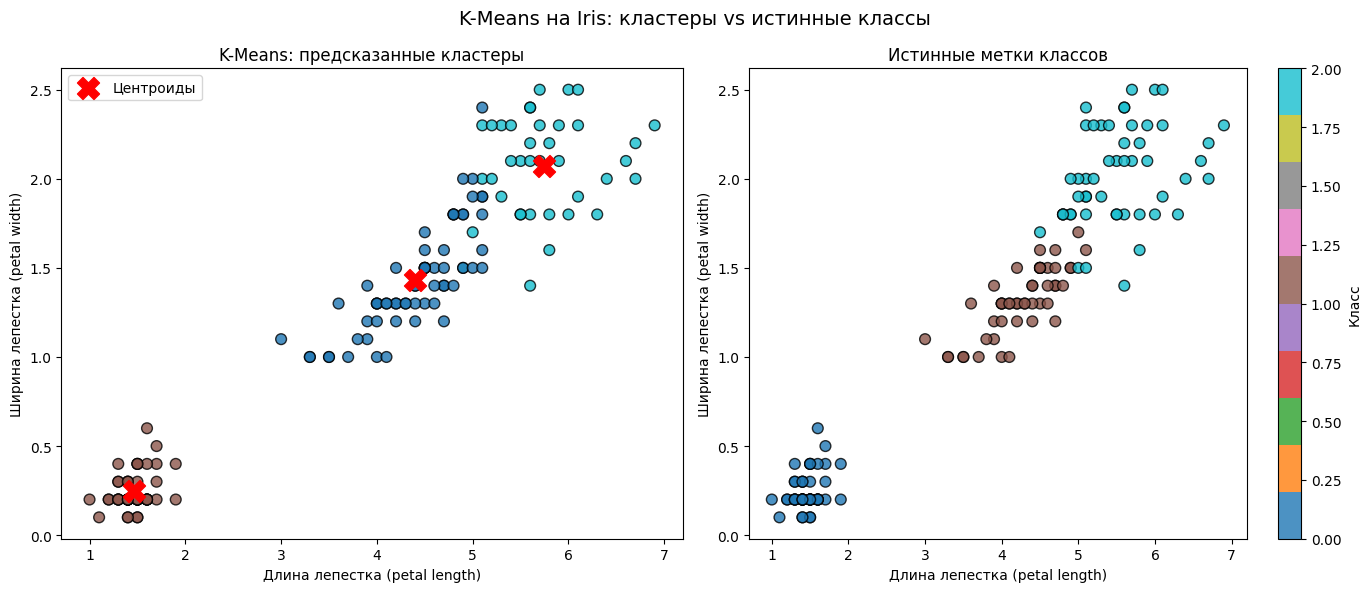

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_iris[:, 2], X_iris[:, 3],
    c=labels_iris, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[0].scatter(
    kmeans_iris.cluster_centers_[:, 2],
    kmeans_iris.cluster_centers_[:, 3],
    c='red', marker='X', s=250, zorder=5, label='Центроиды'
)
axes[0].set_xlabel('Длина лепестка (petal length)')
axes[0].set_ylabel('Ширина лепестка (petal width)')
axes[0].set_title('K-Means: предсказанные кластеры')
axes[0].legend()

scatter = axes[1].scatter(
    X_iris[:, 2], X_iris[:, 3],
    c=y_iris, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[1].set_xlabel('Длина лепестка (petal length)')
axes[1].set_ylabel('Ширина лепестка (petal width)')
axes[1].set_title('Истинные метки классов')
plt.colorbar(scatter, ax=axes[1], label='Класс')

plt.suptitle('K-Means на Iris: кластеры vs истинные классы', fontsize=14)
plt.tight_layout()
plt.show()

## Прогнозы модели

Рассматриваем полученные кластерные метки и сравниваем их с истинными классами датасета `Iris`


In [19]:
print('Первые 15 предсказанных кластерных меток для Iris:')
print(labels_iris[:15])


Первые 15 предсказанных кластерных меток для Iris:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [20]:
ari = adjusted_rand_score(y_iris, labels_iris)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print("(ARI=1.0 — идеальное совпадение, ARI=0 — случайное)")

print("\nТаблица соответствия (истинный класс → кластер K-Means):")
comparison = pd.crosstab(
    pd.Series(y_iris, name='Истинный класс').map(dict(enumerate(target_names))),
    pd.Series(labels_iris, name='Кластер K-Means')
)
print(comparison)

Adjusted Rand Index (ARI): 0.7302
(ARI=1.0 — идеальное совпадение, ARI=0 — случайное)

Таблица соответствия (истинный класс → кластер K-Means):
Кластер K-Means   0   1   2
Истинный класс             
setosa            0  50   0
versicolor       48   0   2
virginica        14   0  36


## K-Means++ на датасете Iris

Применим K-Means++ к Iris отдельно и сравним результат со стандартным K-Means (случайная инициализация) по инерции и ARI.

In [21]:
kmeans_random_iris = KMeans(n_clusters=3, init='random', n_init=10, random_state=42)
kmeans_random_iris.fit(X_iris)

kmeans_pp_iris = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_pp_iris.fit(X_iris)

ari_random = adjusted_rand_score(y_iris, kmeans_random_iris.labels_)
ari_pp = adjusted_rand_score(y_iris, kmeans_pp_iris.labels_)

print("Сравнение K-Means и K-Means++ на Iris:")
print(f"  {'Метод':<15} {'Инерция':>10} {'Итераций':>10} {'ARI':>8}")
print(f"  {'random':<15} {kmeans_random_iris.inertia_:>10.2f} {kmeans_random_iris.n_iter_:>10} {ari_random:>8.4f}")
print(f"  {'k-means++':<15} {kmeans_pp_iris.inertia_:>10.2f} {kmeans_pp_iris.n_iter_:>10} {ari_pp:>8.4f}")

Сравнение K-Means и K-Means++ на Iris:
  Метод              Инерция   Итераций      ARI
  random               78.85          6   0.7302
  k-means++            78.85          4   0.7302


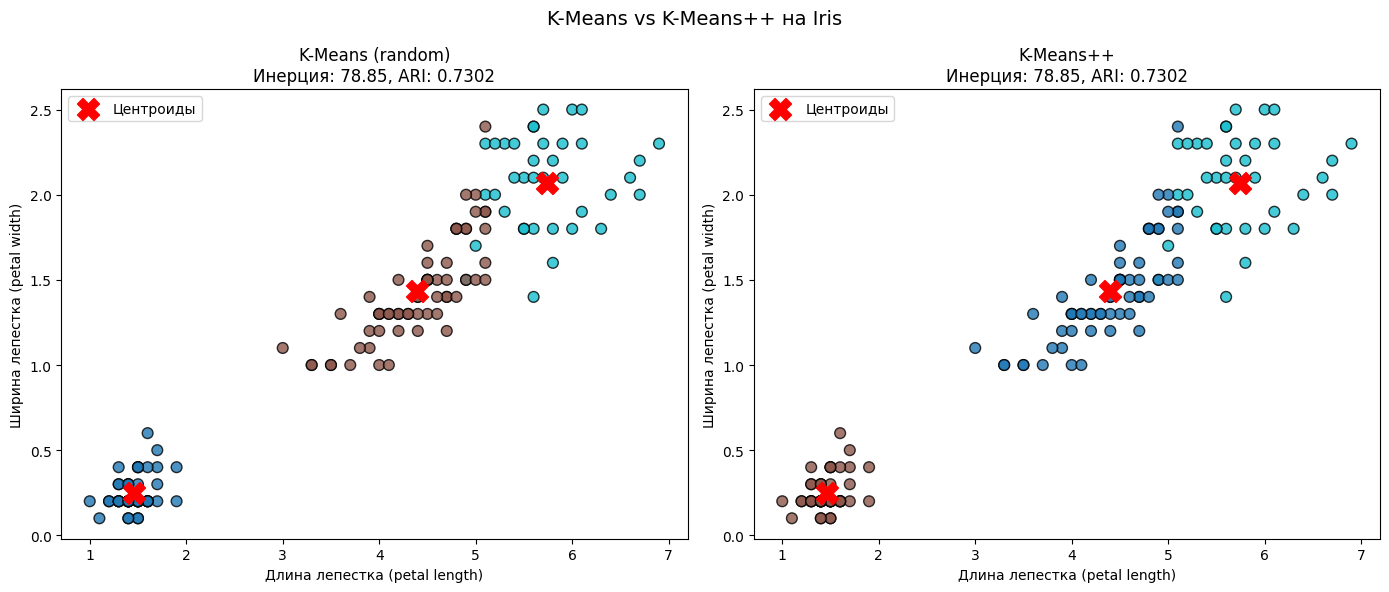

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(
    axes,
    [kmeans_random_iris, kmeans_pp_iris],
    ['K-Means (random)', 'K-Means++']
):
    ari = adjusted_rand_score(y_iris, model.labels_)
    ax.scatter(
        X_iris[:, 2], X_iris[:, 3],
        c=model.labels_, cmap='tab10', edgecolor='black', s=60, alpha=0.8
    )
    ax.scatter(
        model.cluster_centers_[:, 2], model.cluster_centers_[:, 3],
        c='red', marker='X', s=250, zorder=5, label='Центроиды'
    )
    ax.set_xlabel('Длина лепестка (petal length)')
    ax.set_ylabel('Ширина лепестка (petal width)')
    ax.set_title(f'{title}\nИнерция: {model.inertia_:.2f}, ARI: {ari:.4f}')
    ax.legend()

plt.suptitle('K-Means vs K-Means++ на Iris', fontsize=14)
plt.tight_layout()
plt.show()

## Влияние масштабирования

Сравним результаты K-Means с `StandardScaler` и без него.

In [23]:
kmeans_noscale = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_noscale.fit(X_iris)
labels_noscale = kmeans_noscale.labels_

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

kmeans_scaled = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_scaled.fit(X_iris_scaled)
labels_scaled = kmeans_scaled.labels_

ari_noscale = adjusted_rand_score(y_iris, labels_noscale)
ari_scaled = adjusted_rand_score(y_iris, labels_scaled)

print("Сравнение качества кластеризации (Adjusted Rand Index):")
print(f"  Без масштабирования: ARI = {ari_noscale:.4f}, инерция = {kmeans_noscale.inertia_:.4f}")
print(f"  С масштабированием:  ARI = {ari_scaled:.4f}, инерция = {kmeans_scaled.inertia_:.4f}")

Сравнение качества кластеризации (Adjusted Rand Index):
  Без масштабирования: ARI = 0.7302, инерция = 78.8514
  С масштабированием:  ARI = 0.6201, инерция = 139.8205


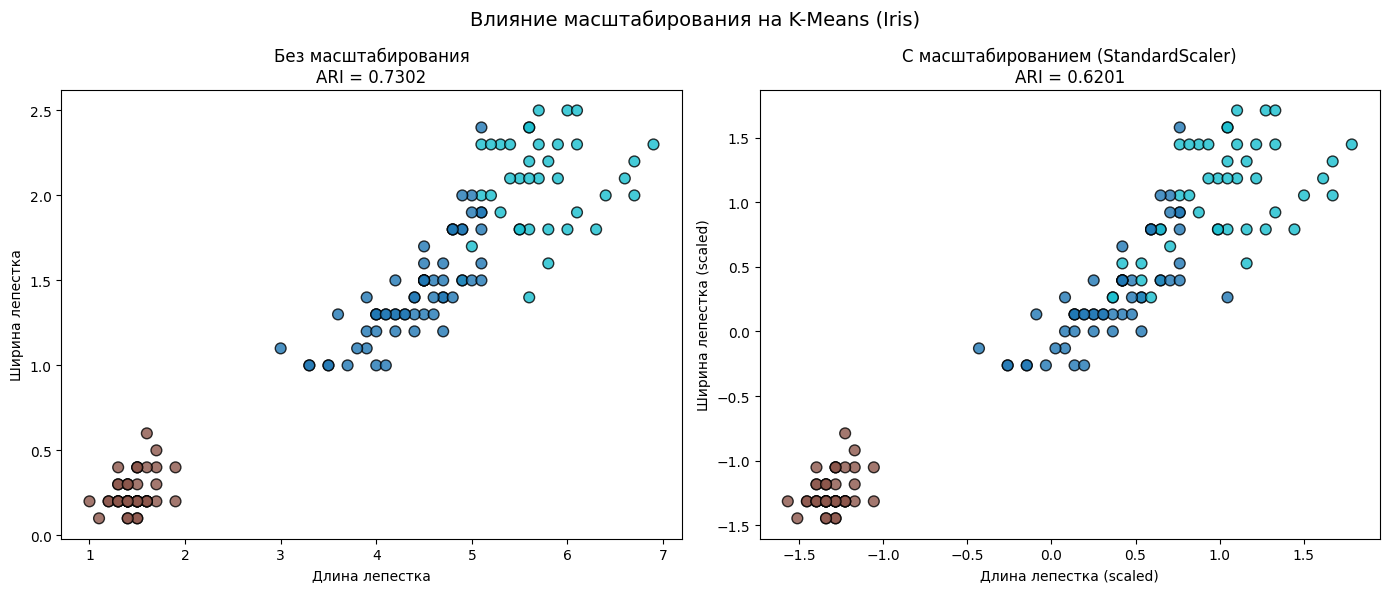

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_iris[:, 2], X_iris[:, 3],
    c=labels_noscale, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[0].set_xlabel('Длина лепестка')
axes[0].set_ylabel('Ширина лепестка')
axes[0].set_title(f'Без масштабирования\nARI = {ari_noscale:.4f}')

axes[1].scatter(
    X_iris_scaled[:, 2], X_iris_scaled[:, 3],
    c=labels_scaled, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[1].set_xlabel('Длина лепестка (scaled)')
axes[1].set_ylabel('Ширина лепестка (scaled)')
axes[1].set_title(f'С масштабированием (StandardScaler)\nARI = {ari_scaled:.4f}')

plt.suptitle('Влияние масштабирования на K-Means (Iris)', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
print("Таблица соответствия БЕЗ масштабирования (истинный класс → кластер):")
comp_noscale = pd.crosstab(
    pd.Series(y_iris, name='Истинный класс').map(dict(enumerate(target_names))),
    pd.Series(labels_noscale, name='Кластер')
)
print(comp_noscale)

print("\nТаблица соответствия С масштабированием (истинный класс → кластер):")
comp_scaled = pd.crosstab(
    pd.Series(y_iris, name='Истинный класс').map(dict(enumerate(target_names))),
    pd.Series(labels_scaled, name='Кластер')
)
print(comp_scaled)

Таблица соответствия БЕЗ масштабирования (истинный класс → кластер):
Кластер          0   1   2
Истинный класс            
setosa           0  50   0
versicolor      48   0   2
virginica       14   0  36

Таблица соответствия С масштабированием (истинный класс → кластер):
Кластер          0   1   2
Истинный класс            
setosa           0  50   0
versicolor      39   0  11
virginica       14   0  36
